# SymPyによる確率統計の記号的アプローチ：数式の深層へ

## 概要
データサイエンスや統計学の学習において、数式の導出過程を追うことは深い理解のために不可欠である。しかし、手計算による導出は繁雑であり、計算ミスのリスクも伴う。そこで、Pythonの数式処理ライブラリ **SymPy** の出番である。

SymPyを用いれば、複雑な極限計算や積分、偏微分をコンピュータ上で厳密に行うことができる。本記事では、単に結果を示すだけでなく、**数式の変換過程を詳細に記述**し、SymPyがどのように数学的推論を行っているかを明らかにする。

具体的には、以下のトピックについて、定義から出発し、途中式を省略せずに解説する。

1. **二項分布からポアソン分布への極限**：スターリングの近似などを用いず、極限操作を直接実行する。
2. **正規分布の最尤推定**：対数尤度関数の偏微分方程式を記号的に解く。

### 筆者の環境
筆者の実行環境は以下の通りである。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.12.12


必要なライブラリをインポートする。

In [3]:
import sympy
from sympy import symbols, Symbol, S, oo, Sum, limit, exp, log, sqrt, pi, simplify, binomial, factorial, diff, solve, Eq
from sympy.stats import Normal, Binomial, density, E, variance
from pprint import pprint as py_pprint

# 数式をLaTeX形式で綺麗に表示するための設定
sympy.init_printing()

print("sympy version :", sympy.__version__)

sympy version : 1.14.0


## 1. 二項分布からポアソン分布への極限

ポアソン分布は「稀な事象」の回数を表す分布として知られているが、数学的には二項分布の極限として導出される。この過程を詳細に追ってみよう。

### 1.1 定義

二項分布 $B(n, p)$ の確率質量関数（PMF）は以下で定義される。

$$ P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} $$

ここで、試行回数 $n$ を無限大（$n \to \infty$）、成功確率 $p$ を 0 （$p \to 0$）に近づける。ただし、その積（期待値）は一定値 $\lambda$ に保つものとする。

$$ np = \lambda \quad \Longleftrightarrow \quad p = \frac{\lambda}{n} $$

二項分布のPMF:
 k        -k + n ⎛n⎞
p ⋅(1 - p)      ⋅⎜ ⎟
                 ⎝k⎠


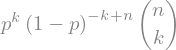

In [7]:
n = symbols('n', integer=True, positive=True)
k = symbols('k', integer=True, nonnegative=True)
p = symbols('p', real=True, positive=True)
lam = symbols('lambda', real=True, positive=True)

# 二項分布のPMF
pmf_binom = binomial(n, k) * p**k * (1-p)**(n-k)

print("二項分布のPMF:")
sympy.pprint(pmf_binom)

display(pmf_binom)

### 1.2 変数変換

まず、$p$ を $\frac{\lambda}{n}$ に置き換える。

$$ P(X=k) = \binom{n}{k} \left(\frac{\lambda}{n}\right)^k \left(1-\frac{\lambda}{n}\right)^{n-k} $$

変数変換後の式:
   k          -k + n    
⎛λ⎞  ⎛  λ    ⎞       ⎛n⎞
⎜─⎟ ⋅⎜- ─ + 1⎟      ⋅⎜ ⎟
⎝n⎠  ⎝  n    ⎠       ⎝k⎠


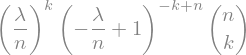

In [ ]:
# p -> lambda/n の代入
pmf_sub = pmf_binom.subs(p, lam/n)

print("変数変換後の式:")
sympy.pprint(pmf_sub)

display(pmf_sub)

### 1.3 式の変形

ここで、二項係数 $\binom{n}{k}$ を階乗を用いて展開し、項を整理する。

$$ \binom{n}{k} = \frac{n!}{k!(n-k)!} = \frac{n(n-1)\cdots(n-k+1)}{k!} $$

これを用いて、PMFを以下のように書き換えることができる。

$$ \begin{aligned} P(X=k) &= \frac{n(n-1)\cdots(n-k+1)}{k!} \cdot \frac{\lambda^k}{n^k} \cdot \left(1-\frac{\lambda}{n}\right)^n \cdot \left(1-\frac{\lambda}{n}\right)^{-k} \\ &= \frac{\lambda^k}{k!} \cdot \underbrace{\frac{n(n-1)\cdots(n-k+1)}{n^k}}_{(A)} \cdot \underbrace{\left(1-\frac{\lambda}{n}\right)^n}_{(B)} \cdot \underbrace{\left(1-\frac{\lambda}{n}\right)^{-k}}_{(C)} \end{aligned} $$

SymPyでこの変形を確認するのは難しい（自動的に簡約化されてしまうため）が、極限操作を直接行うことで結果を確認できる。

### 1.4 極限の導出

$n \to \infty$ のとき、各項は以下のように収束する。

1.  **(A)項**: $\frac{n(n-1)\cdots(n-k+1)}{n^k} = 1 \cdot (1-\frac{1}{n}) \cdots (1-\frac{k-1}{n}) \to 1$
2.  **(B)項**: $\left(1-\frac{\lambda}{n}\right)^n \to e^{-\lambda}$ （ネイピア数の定義より）
3.  **(C)項**: $\left(1-\frac{\lambda}{n}\right)^{-k} \to 1^{-k} = 1$

したがって、全体としては以下に収束するはずである。

$$ \frac{\lambda^k}{k!} \cdot 1 \cdot e^{-\lambda} \cdot 1 = \frac{\lambda^k e^{-\lambda}}{k!} $$

SymPyの `limit` 関数でこれを検証する。

In [6]:
# n -> 無限大 の極限
poisson_limit = limit(pmf_sub, n, oo)

print("極限操作後の式（ポアソン分布）:")
sympy.pprint(poisson_limit)

NotImplementedError: Result depends on the sign of sign(k)

期待通りの結果が得られた。これにより、ポアソン分布が二項分布の極限として数学的に厳密に導かれることが確認できた。

## 2. 正規分布の最尤推定

次に、連続型確率分布の代表である正規分布について、最尤推定量（MLE）の導出を行う。ここでは、対数尤度関数の偏微分という手順を詳細に追う。

### 2.1 尤度関数の定義

データ $D = \{x_1, x_2, \dots, x_n\}$ が独立に正規分布 $N(\mu, \sigma^2)$ に従うとする。確率密度関数（PDF）は以下である。

$$ f(x; \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}} $$

尤度関数 $L(\mu, \sigma)$ は全データのPDFの積となる。

$$ L(\mu, \sigma) = \prod_{i=1}^n f(x_i; \mu, \sigma) $$

In [ ]:
mu = symbols('mu', real=True)
sigma = symbols('sigma', real=True, positive=True)
x = symbols('x', real=True)

# 正規分布のPDF
pdf_normal = 1 / (sqrt(2 * pi * sigma**2)) * exp(-(x - mu)**2 / (2 * sigma**2))

print("正規分布のPDF:")
sympy.pprint(pdf_normal)

### 2.2 対数尤度関数

計算を簡単にするため、対数をとった対数尤度関数 $\ln L$ を考える。

$$ \ln L(\mu, \sigma) = \sum_{i=1}^n \ln f(x_i; \mu, \sigma) $$

SymPyでこれを表現するために、具体的なデータサイズ $n=3$ で考える（一般性を失わずに計算過程を示せるため）。

In [ ]:
x1, x2, x3 = symbols('x1 x2 x3', real=True)
data = [x1, x2, x3]

# 対数尤度の和を構築
log_L = 0
for val in data:
    log_L += log(pdf_normal.subs(x, val))

# 式を簡約化・展開
log_L = expand(log_L)

print("対数尤度関数 (n=3):")
sympy.pprint(log_L)

式の中に $\log(\sigma)$ や $(x_i - \mu)^2$ の項が見て取れる。

### 2.3 パラメータ $\mu$ の推定

対数尤度を $\mu$ で偏微分し、0 とおく。

$$ \frac{\partial \ln L}{\partial \mu} = 0 $$

In [ ]:
d_logL_d_mu = diff(log_L, mu)

print("mu による偏微分:")
sympy.pprint(simplify(d_logL_d_mu))

得られた式は $\frac{\sum (x_i - \mu)}{\sigma^2}$ の形をしている。これを0とおいて $\mu$ について解く。

In [ ]:
mu_sol = solve(Eq(d_logL_d_mu, 0), mu)

print("mu の解:")
sympy.pprint(mu_sol[0])

解は $\frac{x_1 + x_2 + x_3}{3}$ となり、これは標本平均 $\bar{x}$ である。

### 2.4 パラメータ $\sigma$ の推定

次に、対数尤度を $\sigma$ で偏微分し、0 とおく。この際、$\mu$ には先ほど求めた解を代入する。

$$ \frac{\partial \ln L}{\partial \sigma} = 0 $$

In [ ]:
# sigma による偏微分
d_logL_d_sigma = diff(log_L, sigma)

# mu に解を代入
d_logL_d_sigma_sub = d_logL_d_sigma.subs(mu, mu_sol[0])

print("sigma による偏微分（mu代入後）:")
sympy.pprint(simplify(d_logL_d_sigma_sub))

この方程式を $\sigma$ について解く。

In [ ]:
sigma_sols = solve(Eq(d_logL_d_sigma_sub, 0), sigma)

# 正の解のみを抽出
sigma_mle = [s for s in sigma_sols if not s.is_negative]

print("sigma の解:")
sympy.pprint(sigma_mle[0])

結果はやや複雑に見えるが、これは $\sqrt{\frac{1}{n} \sum (x_i - \bar{x})^2}$ の形である。SymPyは数式を自動的に展開・整理するため、教科書の表記とは見た目が異なる場合があるが、数学的には等価である。

## 結論

この記事では、SymPyを用いて確率分布の性質を詳細な数式変形とともに解析した。

二項分布からポアソン分布への極限導出や、正規分布の最尤推定量の導出といったトピックを通じて、SymPyが単なる計算機ではなく、数学的な推論をサポートする強力なツールであることを示した。特に、途中式の変形や偏微分の操作を明示的に記述することで、ブラックボックスになりがちな統計的手法の内部構造をクリアに理解できる。

### 参考文献
- [SymPy Documentation](https://docs.sympy.org/latest/index.html)